# EDA - Data Análisis de AIRBNB

### Proyecto Grupal — Data Análisis de airbnb en diferentes ciudades ( london, madrid, milan, NY, sydney y tokyo)

---

Antes de empezar, comentar que se han revisado los datasets con excel o programas similares y se ha observado lo siguiente :

- El dataset de *Tokyo* tiene caracteres en japonés -> Habrá que traducirlos a inglés.
- Revisar si las columnas de **latitude** y **longitude** son numéricas.
- La columna **price** tiene precios en diferentes monedas -> unificarlo todo a euros. Los datos de media son del año 2019. Habrá que poner el cambio de moneda de ese año.
- La columna **last_review** contiene fechas -> unificarlo todo para que tengan datos de tipo fecha y en el mismo formato todas (yyy-mm-dd).
- Verificar que la columna **room_type** tiene valores iguales en todos los datasets.
- Crear ua columna nueva llamada **city** con el nombre de la ciudad.
- Antes de fusionar todos los datasets verificar los nombres de las columnas para que sean iguales.

---

## 📖 ¿Qué es un EDA y para qué sirve?

El **Análisis Exploratorio de Datos (EDA)** es el primer paso de todo proyecto.  
Antes de entrenar cualquier modelo, necesitamos **entender** los datos:
- ¿Qué hay en el dataset?
- ¿Los datos están limpios o tienen errores?
- ¿Qué variables son importantes?
- ¿Hay patrones o relaciones entre variables?

**Analogía:** El EDA es como leer el manual de instrucciones antes de montar un mueble. Puedes saltártelo, pero luego te sobran tornillos.

---

## 🗺️ Hoja de Ruta del Notebook

| Sección | Qué vamos a hacer |
|--------|-------------------|
| **1** | Importar librerías y cargar datos |
| **2** | Primera inspección de los datasets y fusión en un único dataset |
| **3** | Inspección del dataset fusionado y Análisis de valores nulos |

| **4** | Análisis de variables numéricas |
| **5** | Análisis de variables categóricas |
| **6** | Correlaciones entre variables |
| **7** | Detección de outliers |
| **8** | Conclusiones y próximos pasos |

---

# Sección 1

### Importando librerías

In [68]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

### Leyendo archivos en formato csv de airbnb de diferentes ciudades

#### leyendo archivo de london_airbnb.csv

In [69]:
df_london = pd.read_csv('../data/raw/london_airbnb.csv')

# Obtener filas y columnas
filas, columnas = df_london.shape
print(f'✅ Dataset london_airbnb cargado correctamente')
print(f'📊 Dimensiones: {filas} filas x {columnas} columnas')

✅ Dataset london_airbnb cargado correctamente
📊 Dimensiones: 85068 filas x 16 columnas


#### leyendo archivo de madrid_airbnb.csv

In [70]:
df_madrid = pd.read_csv('../data/raw/madrid_airbnb.csv')

# Obtener filas y columnas
filas, columnas = df_madrid.shape
print(f'✅ Dataset madrid_airbnb cargado correctamente')
print(f'📊 Dimensiones: {filas} filas x {columnas} columnas')

✅ Dataset madrid_airbnb cargado correctamente
📊 Dimensiones: 19618 filas x 16 columnas


#### leyendo archivo de milan_airbnb.csv

In [71]:
df_milan = pd.read_csv('../data/raw/milan_airbnb.csv')

# Obtener filas y columnas
filas, columnas = df_milan.shape
print(f'✅ Dataset milan_airbnb cargado correctamente')
print(f'📊 Dimensiones: {filas} filas x {columnas} columnas')

✅ Dataset milan_airbnb cargado correctamente
📊 Dimensiones: 18322 filas x 15 columnas


#### leyendo archivo de NY_airbnb.csv

In [72]:
df_ny = pd.read_csv('../data/raw/NY_airbnb.csv')

# Obtener filas y columnas
filas, columnas = df_ny.shape
print(f'✅ Dataset NY_airbnb cargado correctamente')
print(f'📊 Dimensiones: {filas} filas x {columnas} columnas')

✅ Dataset NY_airbnb cargado correctamente
📊 Dimensiones: 48895 filas x 16 columnas


#### leyendo archivo de sydney_airbnb.csv

In [73]:
df_sydney = pd.read_csv('../data/raw/sydney_airbnb.csv')

# Obtener filas y columnas
filas, columnas = df_sydney.shape
print(f'✅ Dataset sydney_airbnb cargado correctamente')
print(f'📊 Dimensiones: {filas} filas x {columnas} columnas')

✅ Dataset sydney_airbnb cargado correctamente
📊 Dimensiones: 36662 filas x 16 columnas


#### leyendo archivo de tokyo_airbnb.csv

In [74]:
df_tokyo = pd.read_csv('../data/raw/tokyo_airbnb.csv')

# Obtener filas y columnas
filas, columnas = df_tokyo.shape
print(f'✅ Dataset tokyo_airbnb cargado correctamente')
print(f'📊 Dimensiones: {filas} filas x {columnas} columnas')

✅ Dataset tokyo_airbnb cargado correctamente
📊 Dimensiones: 11466 filas x 14 columnas


# Sección 2

### Primera inspección de los datasets antes de fusionarlos

#### Dataset df_london

In [75]:
# Información general del dataset
print('ℹ️ Información del dataset df_london:')
df_london.info()

ℹ️ Información del dataset df_london:
<class 'pandas.DataFrame'>
RangeIndex: 85068 entries, 0 to 85067
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              85068 non-null  int64  
 1   name                            85042 non-null  str    
 2   host_id                         85068 non-null  int64  
 3   host_name                       85056 non-null  str    
 4   neighbourhood_group             0 non-null      float64
 5   neighbourhood                   85068 non-null  str    
 6   latitude                        85068 non-null  float64
 7   longitude                       85068 non-null  float64
 8   room_type                       85068 non-null  str    
 9   price                           85068 non-null  int64  
 10  minimum_nights                  85068 non-null  int64  
 11  number_of_reviews               85068 non-null  int64  
 12  last_

---

- No hay nulos en ninguna columna.
- La columna *neighbourhood_group* no contiene datos, es float64 y contiene NaN.
- Las columnas *latitude* y *longitude* son numéricas.
- La columna *price* contiene el precio en libras y hay que convertirlo a euros - 1 euro = 0.877 libras esterlinas en 2019.
- La columna last_review es de tipo str pero contiene fechas y debe ser de tipo date y en formato yyyy-mm-dd.

---

In [76]:
# Convertir la columna last_review a tipo fecha
df_london['last_review'] = pd.to_datetime(df_london['last_review'], format='%Y-%m-%d', errors='coerce')
df_london['last_review'].dtype

dtype('<M8[us]')

In [77]:
df_london.info()

<class 'pandas.DataFrame'>
RangeIndex: 85068 entries, 0 to 85067
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype         
---  ------                          --------------  -----         
 0   id                              85068 non-null  int64         
 1   name                            85042 non-null  str           
 2   host_id                         85068 non-null  int64         
 3   host_name                       85056 non-null  str           
 4   neighbourhood_group             0 non-null      float64       
 5   neighbourhood                   85068 non-null  str           
 6   latitude                        85068 non-null  float64       
 7   longitude                       85068 non-null  float64       
 8   room_type                       85068 non-null  str           
 9   price                           85068 non-null  int64         
 10  minimum_nights                  85068 non-null  int64         
 11  number_of_rev

In [78]:
# Cambiar el price a euros
df_london['price'] = (df_london['price'] / 0.877).round(2)

In [79]:
# Ver valores únicos de la columna room_type
df_london['room_type'].unique()

<StringArray>
['Entire home/apt', 'Private room', 'Hotel room', 'Shared room']
Length: 4, dtype: str

In [80]:
# Crear la columna city con el nombre de la ciudad
df_london['city'] = 'London'

In [81]:
df_london.head(5)

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,city
0,11551,Arty and Bright London Apartment in Zone 2,43039,Adriano,NaN,Lambeth,51.46225,-0.11732,Entire home/apt,100.34,3,185,2019-09-15,1.58,2,336,London
1,13913,Holiday London DB Room Let-on going,54730,Alina,NaN,Islington,51.56802,-0.11121,Private room,74.12,1,19,2019-10-07,0.17,2,365,London
2,90700,Sunny Notting Hill flat & terrace,491286,Chil,NaN,Kensington and Chelsea,51.51074,-0.19853,Entire home/apt,119.73,2,339,2019-07-30,3.33,2,268,London
3,15400,Bright Chelsea Apartment. Chelsea!,60302,Philippa,NaN,Kensington and Chelsea,51.48796,-0.16898,Entire home/apt,114.03,30,88,2019-09-23,0.73,1,158,London
4,92399,"MODERN SELF CONTAINED ARCHITECT FLATLET, ISLIN...",497366,Andrea & Mark,NaN,Islington,51.55071,-0.08547,Private room,87.80,1,207,2019-10-21,2.04,2,336,London


In [82]:
df_london.describe()

,id,host_id,neighbourhood_group,latitude,longitude,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
count,8.506800e+04,8.506800e+04,0.0,85068.000000,85068.000000,85068.000000,85068.000000,85068.000000,65062,65062.000000,85068.000000,85068.000000
mean,2.319997e+07,8.514442e+07,NaN,51.509798,-0.128343,139.495103,4.148105,17.471152,2019-03-08 01:56:15.795395,1.201995,22.151150,118.471987
min,1.155100e+04,2.697000e+03,NaN,51.294790,-0.496680,0.000000,1.000000,0.000000,2011-07-02 00:00:00,0.010000,1.000000,0.000000
25%,1.441315e+07,1.529856e+07,NaN,51.485610,-0.188412,53.590000,1.000000,1.000000,2018-12-29 00:00:00,0.250000,1.000000,0.000000
50%,2.363201e+07,4.762387e+07,NaN,51.514015,-0.125725,95.780000,2.000000,4.000000,2019-08-29 00:00:00,0.730000,1.000000,58.000000
75%,3.349281e+07,1.415435e+08,NaN,51.537580,-0.070127,159.640000,3.000000,17.000000,2019-10-18 00:00:00,1.630000,5.000000,244.000000
max,3.988030e+07,3.070013e+08,NaN,51.681690,0.285390,14076.400000,1125.000000,716.000000,2019-11-06 00:00:00,20.130000,999.000000,365.000000
std,1.132475e+07,8.603532e+07,NaN,0.046341,0.093034,251.709348,16.681720,36.789578,NaN,1.402728,110.654631,134.840097


#### Dataset df_madrid

In [83]:
# Información general del dataset
print('ℹ️ Información del dataset df_madrid:')
df_madrid.info()

ℹ️ Información del dataset df_madrid:
<class 'pandas.DataFrame'>
RangeIndex: 19618 entries, 0 to 19617
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              19618 non-null  int64  
 1   name                            19615 non-null  str    
 2   host_id                         19618 non-null  int64  
 3   host_name                       19091 non-null  str    
 4   neighbourhood_group             19618 non-null  str    
 5   neighbourhood                   19618 non-null  str    
 6   latitude                        19618 non-null  float64
 7   longitude                       19618 non-null  float64
 8   room_type                       19618 non-null  str    
 9   price                           19618 non-null  int64  
 10  minimum_nights                  19618 non-null  int64  
 11  number_of_reviews               19618 non-null  int64  
 12  last_

---

- No hay nulos en ninguna columna.
- La columna *neighbourhood_group* es de tipo str.
- Las columnas *latitude* y *longitude* son numéricas.
- La columna *price* contiene el precio y suponemos que es en euros.
- La columna last_review es de tipo str pero contiene fechas y debe ser de tipo date y en formato yyyy-mm-dd.

---

In [84]:
# Convertir la columna last_review a tipo fecha
df_madrid['last_review'] = pd.to_datetime(df_madrid['last_review'], format='%Y-%m-%d', errors='coerce')
df_madrid['last_review'].dtype

dtype('<M8[us]')

In [85]:
df_madrid.info()

<class 'pandas.DataFrame'>
RangeIndex: 19618 entries, 0 to 19617
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype         
---  ------                          --------------  -----         
 0   id                              19618 non-null  int64         
 1   name                            19615 non-null  str           
 2   host_id                         19618 non-null  int64         
 3   host_name                       19091 non-null  str           
 4   neighbourhood_group             19618 non-null  str           
 5   neighbourhood                   19618 non-null  str           
 6   latitude                        19618 non-null  float64       
 7   longitude                       19618 non-null  float64       
 8   room_type                       19618 non-null  str           
 9   price                           19618 non-null  int64         
 10  minimum_nights                  19618 non-null  int64         
 11  number_of_rev

In [86]:
# Ver valores únicos de la columna room_type
df_madrid['room_type'].unique()

<StringArray>
['Private room', 'Entire home/apt', 'Shared room', 'Hotel room']
Length: 4, dtype: str

In [87]:
# Crear la columna city con el nombre de la ciudad
df_madrid['city'] = 'Madrid'

In [88]:
df_madrid.head(5)

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,city
0,6369,"Rooftop terrace room , ensuite bathroom",13660,Simon,Chamartín,Hispanoamérica,40.45724,-3.67688,Private room,60,1,78,2020-09-20,0.58,1,180,Madrid
1,21853,Bright and airy room,83531,Abdel,Latina,Cármenes,40.40381,-3.74130,Private room,31,4,33,2018-07-15,0.42,2,364,Madrid
2,23001,Apartmento Arganzuela- Madrid Rio,82175,Jesus,Arganzuela,Legazpi,40.38840,-3.69511,Entire home/apt,50,15,0,NaT,NaN,7,1,Madrid
3,24805,Gran Via Studio Madrid,346366726,A,Centro,Universidad,40.42183,-3.70529,Entire home/apt,92,5,10,2020-03-01,0.13,1,72,Madrid
4,26825,Single Room whith private Bathroom,114340,Agustina,Arganzuela,Legazpi,40.38975,-3.69018,Private room,26,2,149,2020-03-12,1.12,1,365,Madrid


In [89]:
df_madrid.describe()

,id,host_id,latitude,longitude,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
count,1.961800e+04,1.961800e+04,19618.000000,19618.000000,19618.000000,19618.000000,19618.000000,13981,13981.000000,19618.000000,19618.000000
mean,2.912200e+07,1.312165e+08,40.420984,-3.694040,129.271740,6.586196,31.858803,2020-02-16 23:45:53.365281,1.125958,10.229177,159.098328
min,6.369000e+03,7.952000e+03,40.332210,-3.863910,0.000000,1.000000,0.000000,2012-05-28 00:00:00,0.010000,1.000000,0.000000
25%,1.903424e+07,2.765313e+07,40.409393,-3.707700,35.000000,1.000000,0.000000,2019-10-25 00:00:00,0.170000,1.000000,0.000000
50%,3.187506e+07,9.901898e+07,40.419735,-3.701120,58.000000,2.000000,4.000000,2020-03-08 00:00:00,0.590000,2.000000,126.000000
75%,4.090994e+07,2.256898e+08,40.430290,-3.685420,100.000000,3.000000,31.000000,2021-02-03 00:00:00,1.630000,6.000000,320.000000
max,4.918779e+07,3.964281e+08,40.562740,-3.531900,9999.000000,1125.000000,706.000000,2021-04-17 00:00:00,16.220000,163.000000,365.000000
std,1.351839e+07,1.166790e+08,0.022627,0.028671,484.143545,33.286582,63.938997,NaN,1.348235,23.546472,144.252803


#### Dataset df_milan

In [90]:
# Información general del dataset
print('ℹ️ Información del dataset df_milan:')
df_milan.info()

ℹ️ Información del dataset df_milan:
<class 'pandas.DataFrame'>
RangeIndex: 18322 entries, 0 to 18321
Data columns (total 15 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              18322 non-null  int64  
 1   name                            18312 non-null  str    
 2   host_id                         18322 non-null  int64  
 3   host_name                       18198 non-null  str    
 4   neighbourhood                   18322 non-null  str    
 5   latitude                        18322 non-null  float64
 6   longitude                       18322 non-null  float64
 7   room_type                       18322 non-null  str    
 8   price                           18322 non-null  int64  
 9   minimum_nights                  18322 non-null  int64  
 10  number_of_reviews               18322 non-null  int64  
 11  last_review                     13260 non-null  str    
 12  review

---

- No hay nulos en ninguna columna.
- La columna *neighbourhood_group* No existe en este Dataset.
- Las columnas *latitude* y *longitude* son numéricas.
- La columna *price* contiene el precio y suponemos que es en euros.
- La columna last_review es de tipo str pero contiene fechas y debe ser de tipo date y en formato yyyy-mm-dd.

---

In [91]:
# Convertir la columna last_review a tipo fecha
df_milan['last_review'] = pd.to_datetime(df_milan['last_review'], format='%d/%m/%y', errors='coerce')
df_milan['last_review'].dtype

dtype('<M8[us]')

In [92]:
df_milan.info()

<class 'pandas.DataFrame'>
RangeIndex: 18322 entries, 0 to 18321
Data columns (total 15 columns):
 #   Column                          Non-Null Count  Dtype         
---  ------                          --------------  -----         
 0   id                              18322 non-null  int64         
 1   name                            18312 non-null  str           
 2   host_id                         18322 non-null  int64         
 3   host_name                       18198 non-null  str           
 4   neighbourhood                   18322 non-null  str           
 5   latitude                        18322 non-null  float64       
 6   longitude                       18322 non-null  float64       
 7   room_type                       18322 non-null  str           
 8   price                           18322 non-null  int64         
 9   minimum_nights                  18322 non-null  int64         
 10  number_of_reviews               18322 non-null  int64         
 11  last_review  

In [93]:
# Ver valores únicos de la columna room_type
df_milan['room_type'].unique()

<StringArray>
['Private room', 'Entire home/apt', 'Shared room', 'Hotel room']
Length: 4, dtype: str

In [94]:
# Crear la columna city con el nombre de la ciudad
df_milan['city'] = 'Milan'

In [95]:
df_milan.head(5)

,id,name,host_id,host_name,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,city
0,6400,The Studio Milan,13822,Francesca,TIBALDI,45.44119,9.17813,Private room,100,4,12,2010-04-19,0.14,1,358,Milan
1,23986,""" Characteristic Milanese flat""",95941,Jeremy,NAVIGLI,45.44806,9.17373,Entire home/apt,150,1,15,2020-09-07,0.21,1,363,Milan
2,28300,nice flat near the park,121663,Marta,SARPI,45.47647,9.17359,Private room,180,1,8,2012-04-22,0.11,1,365,Milan
3,32119,Nico & Cynthia's Easy Yellow Suite,138683,Nico&Cinzia,VIALE MONZA,45.52014,9.22300,Entire home/apt,75,2,15,2018-07-01,0.23,3,200,Milan
4,32649,Nico&Cinzia's Red Easy Suite!,138683,Nico&Cinzia,VIALE MONZA,45.51874,9.22495,Entire home/apt,71,2,29,2016-10-23,0.71,3,308,Milan


In [96]:
df_milan.describe()

,id,host_id,latitude,longitude,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
count,1.832200e+04,1.832200e+04,18322.000000,18322.000000,18322.000000,18322.000000,18322.000000,13260,13260.000000,18322.000000,18322.000000
mean,2.587132e+07,8.494918e+07,45.471318,9.187382,115.094913,5.798112,23.720827,2019-04-13 22:06:04.886877,0.799344,14.421897,153.508624
min,6.400000e+03,1.944000e+03,45.395050,9.060680,8.000000,1.000000,0.000000,2010-04-19 00:00:00,0.010000,1.000000,0.000000
25%,1.214067e+07,1.243642e+07,45.454462,9.168782,50.000000,1.000000,0.000000,2018-05-23 00:00:00,0.100000,1.000000,0.000000
50%,2.588718e+07,3.141304e+07,45.470875,9.186291,73.500000,2.000000,3.000000,2019-09-14 12:00:00,0.310000,1.000000,123.000000
75%,3.926758e+07,1.335227e+08,45.486850,9.209680,110.000000,3.000000,19.000000,2020-02-23 00:00:00,0.990000,4.000000,302.000000
max,5.095505e+07,4.117208e+08,45.539850,9.275280,11999.000000,1124.000000,896.000000,2021-07-11 00:00:00,13.710000,314.000000,365.000000
std,1.525744e+07,1.040579e+08,0.020731,0.029543,290.793019,26.687720,57.657486,NaN,1.220346,46.295635,138.757302


#### Dataset df_ny

In [97]:
# Información general del dataset
print('ℹ️ Información del dataset df_ny:')
df_ny.info()

ℹ️ Información del dataset df_ny:
<class 'pandas.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48895 non-null  int64  
 1   name                            48879 non-null  str    
 2   host_id                         48895 non-null  int64  
 3   host_name                       48874 non-null  str    
 4   neighbourhood_group             48895 non-null  str    
 5   neighbourhood                   48895 non-null  str    
 6   latitude                        48895 non-null  float64
 7   longitude                       48895 non-null  float64
 8   room_type                       48895 non-null  str    
 9   price                           48895 non-null  int64  
 10  minimum_nights                  48895 non-null  int64  
 11  number_of_reviews               48895 non-null  int64  
 12  last_revi

---

- No hay nulos en ninguna columna.
- La columna *neighbourhood_group* es de tipo str.
- Las columnas *latitude* y *longitude* son numéricas.
- La columna *price* contiene el precio en dolares y hay que convertirlo a euros - 1 euro = 1.11 dolares USA en 2019.
- La columna last_review es de tipo str pero contiene fechas y debe ser de tipo date y en formato yyyy-mm-dd.

---

In [98]:
# Convertir la columna last_review a tipo fecha
df_ny['last_review'] = pd.to_datetime(df_ny['last_review'], format='%Y-%m-%d', errors='coerce')
df_ny['last_review'].dtype

dtype('<M8[us]')

In [99]:
df_ny.info()

<class 'pandas.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype         
---  ------                          --------------  -----         
 0   id                              48895 non-null  int64         
 1   name                            48879 non-null  str           
 2   host_id                         48895 non-null  int64         
 3   host_name                       48874 non-null  str           
 4   neighbourhood_group             48895 non-null  str           
 5   neighbourhood                   48895 non-null  str           
 6   latitude                        48895 non-null  float64       
 7   longitude                       48895 non-null  float64       
 8   room_type                       48895 non-null  str           
 9   price                           48895 non-null  int64         
 10  minimum_nights                  48895 non-null  int64         
 11  number_of_rev

In [100]:
# Cambiar el price a euros
df_ny['price'] = (df_ny['price'] / 1.11).round(2)

In [101]:
# Ver valores únicos de la columna room_type
df_ny['room_type'].unique()

<StringArray>
['Private room', 'Entire home/apt', 'Shared room']
Length: 3, dtype: str

In [102]:
# Crear la columna city con el nombre de la ciudad
df_ny['city'] = 'New York'

In [103]:
df_ny.head(5)

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,city
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,134.23,1,9,2018-10-19,0.21,6,365,New York
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,202.70,1,45,2019-05-21,0.38,2,355,New York
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,135.14,3,0,NaT,NaN,1,365,New York
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,80.18,1,270,2019-07-05,4.64,1,194,New York
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,72.07,10,9,2018-11-19,0.10,1,0,New York


In [104]:
df_ny.describe()

,id,host_id,latitude,longitude,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
count,4.889500e+04,4.889500e+04,48895.000000,48895.000000,48895.000000,48895.000000,48895.000000,38843,38843.000000,48895.000000,48895.000000
mean,1.901714e+07,6.762001e+07,40.728949,-73.952170,137.586684,7.029962,23.274466,2018-10-04 01:47:23.910099,1.373221,7.143982,112.781327
min,2.539000e+03,2.438000e+03,40.499790,-74.244420,0.000000,1.000000,0.000000,2011-03-28 00:00:00,0.010000,1.000000,0.000000
25%,9.471945e+06,7.822033e+06,40.690100,-73.983070,62.160000,1.000000,1.000000,2018-07-08 00:00:00,0.190000,1.000000,0.000000
50%,1.967728e+07,3.079382e+07,40.723070,-73.955680,95.500000,3.000000,5.000000,2019-05-19 00:00:00,0.720000,1.000000,45.000000
75%,2.915218e+07,1.074344e+08,40.763115,-73.936275,157.660000,5.000000,24.000000,2019-06-23 00:00:00,2.020000,2.000000,227.000000
max,3.648724e+07,2.743213e+08,40.913060,-73.712990,9009.010000,1250.000000,629.000000,2019-07-08 00:00:00,58.500000,327.000000,365.000000
std,1.098311e+07,7.861097e+07,0.054530,0.046157,216.355145,20.510550,44.550582,NaN,1.680442,32.952519,131.622289


#### Dataset df_sydney

In [105]:
# Información general del dataset
print('ℹ️ Información del dataset df_sydney:')
df_sydney.info()

ℹ️ Información del dataset df_sydney:
<class 'pandas.DataFrame'>
RangeIndex: 36662 entries, 0 to 36661
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              36662 non-null  int64  
 1   name                            36650 non-null  str    
 2   host_id                         36662 non-null  int64  
 3   host_name                       36656 non-null  str    
 4   neighbourhood_group             0 non-null      float64
 5   neighbourhood                   36662 non-null  str    
 6   latitude                        36662 non-null  float64
 7   longitude                       36662 non-null  float64
 8   room_type                       36662 non-null  str    
 9   price                           36662 non-null  int64  
 10  minimum_nights                  36662 non-null  int64  
 11  number_of_reviews               36662 non-null  int64  
 12  last_

---

- No hay nulos en ninguna columna.
- La columna *neighbourhood_group* no contiene datos, es float64 y contiene NaN.
- Las columnas *latitude* y *longitude* son numéricas.
- La columna *price* contiene el precio en dolares australianos AUD y hay que convertirlo a euros - 1 euro = 1.61 dolares Australianos en 2019.
- La columna last_review es de tipo str pero contiene fechas y debe ser de tipo date y en formato yyyy-mm-dd.

---

In [106]:
# Convertir la columna last_review a tipo fecha
df_sydney['last_review'] = pd.to_datetime(df_sydney['last_review'], format='%Y-%m-%d', errors='coerce')
df_sydney['last_review'].dtype

dtype('<M8[us]')

In [107]:
df_sydney.info()

<class 'pandas.DataFrame'>
RangeIndex: 36662 entries, 0 to 36661
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype         
---  ------                          --------------  -----         
 0   id                              36662 non-null  int64         
 1   name                            36650 non-null  str           
 2   host_id                         36662 non-null  int64         
 3   host_name                       36656 non-null  str           
 4   neighbourhood_group             0 non-null      float64       
 5   neighbourhood                   36662 non-null  str           
 6   latitude                        36662 non-null  float64       
 7   longitude                       36662 non-null  float64       
 8   room_type                       36662 non-null  str           
 9   price                           36662 non-null  int64         
 10  minimum_nights                  36662 non-null  int64         
 11  number_of_rev

In [108]:
# Cambiar el price a euros
df_sydney['price'] = (df_sydney['price'] / 1.61).round(2)

In [109]:
# Ver valores únicos de la columna room_type
df_sydney['room_type'].unique()

<StringArray>
['Private room', 'Entire home/apt', 'Shared room']
Length: 3, dtype: str

In [110]:
# Crear la columna city con el nombre de la ciudad
df_sydney['city'] = 'Sydney'

In [111]:
df_sydney.head(5)

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,city
0,12351,Sydney City & Harbour at the door,17061,Stuart,NaN,Sydney,-33.865153,151.191896,Private room,62.11,2,493,2018-11-21,4.83,2,187,Sydney
1,14250,Manly Harbour House,55948,Heidi,NaN,Manly,-33.800929,151.261722,Entire home/apt,292.55,5,1,2016-01-02,0.03,2,321,Sydney
2,15253,Stunning Penthouse Apartment In Heart Of The City,59850,Morag,NaN,Sydney,-33.880455,151.216541,Private room,67.70,2,300,2018-11-16,3.63,2,316,Sydney
3,20865,3 BED HOUSE + 1 BED STUDIO Balmain,64282,Fiona,NaN,Leichhardt,-33.859072,151.172753,Entire home/apt,279.50,7,15,2018-01-07,0.18,1,69,Sydney
4,26174,"COZY PRIVATE ROOM, GREAT LOCATION!",110561,Amanda,NaN,Woollahra,-33.889087,151.259404,Private room,38.51,1,42,2018-11-23,0.45,1,140,Sydney


In [112]:
df_sydney.describe()

,id,host_id,neighbourhood_group,latitude,longitude,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
count,3.666200e+04,3.666200e+04,0.0,36662.000000,36662.000000,36662.000000,36662.000000,36662.000000,24725,24725.000000,36662.000000,36662.000000
mean,1.852083e+07,6.561620e+07,NaN,-33.863112,151.204259,128.999501,5.096885,12.185178,2018-03-16 12:12:15.579373,1.139057,7.115106,97.387595
min,1.235100e+04,8.346000e+03,NaN,-34.135212,150.642903,0.000000,1.000000,0.000000,2011-11-25 00:00:00,0.010000,1.000000,0.000000
25%,1.170461e+07,1.506022e+07,NaN,-33.898444,151.179678,49.690000,1.000000,0.000000,2017-12-30 00:00:00,0.140000,1.000000,0.000000
50%,2.027350e+07,4.134819e+07,NaN,-33.882486,151.215923,84.470000,2.000000,2.000000,2018-08-21 00:00:00,0.490000,1.000000,36.000000
75%,2.524405e+07,1.053605e+08,NaN,-33.832072,151.261413,138.510000,5.000000,9.000000,2018-11-19 00:00:00,1.520000,2.000000,165.000000
max,3.059387e+07,2.294790e+08,NaN,-33.389728,151.339811,9316.150000,1000.000000,493.000000,2018-12-07 00:00:00,15.180000,197.000000,365.000000
std,8.473884e+06,6.374533e+07,NaN,0.071501,0.083529,201.129828,15.664862,28.652548,NaN,1.536521,24.611284,122.969054


#### Dataset df_tokyo

In [113]:
# Información general del dataset
print('ℹ️ Información del dataset df_tokyo:')
df_tokyo.info()

ℹ️ Información del dataset df_tokyo:
<class 'pandas.DataFrame'>
RangeIndex: 11466 entries, 0 to 11465
Data columns (total 14 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   id                   11466 non-null  int64  
 1   name                 11466 non-null  str    
 2   host_id              11466 non-null  int64  
 3   host_name            11450 non-null  str    
 4   neighbourhood_group  0 non-null      float64
 5   neighbourhood        11466 non-null  str    
 6   latitude             11466 non-null  float64
 7   longitude            11466 non-null  float64
 8   room_type            11466 non-null  str    
 9   price                11466 non-null  int64  
 10  minimum_nights       11466 non-null  int64  
 11  number_of_reviews    11466 non-null  int64  
 12  last_review          9789 non-null   str    
 13  reviews_per_month    9789 non-null   float64
dtypes: float64(4), int64(5), str(5)
memory usage: 1.2 MB


---

- No hay nulos en ninguna columna.
- La columna *neighbourhood_group* no contiene datos, es float64 y contiene NaN.
- Las columnas *latitude* y *longitude* son numéricas.
- La columna *price* contiene el precio en yenes JPY y hay que convertirlo a euros - 1 euro = 122 yenes JPY en 2019.
- La columna last_review es de tipo str pero contiene fechas y debe ser de tipo date y en formato yyyy-mm-dd.

---

In [114]:
# Convertir la columna last_review a tipo fecha
df_tokyo['last_review'] = pd.to_datetime(df_tokyo['last_review'], format='%Y-%m-%d', errors='coerce')
df_tokyo['last_review'].dtype

dtype('<M8[us]')

In [115]:
df_tokyo.info()

<class 'pandas.DataFrame'>
RangeIndex: 11466 entries, 0 to 11465
Data columns (total 14 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   id                   11466 non-null  int64         
 1   name                 11466 non-null  str           
 2   host_id              11466 non-null  int64         
 3   host_name            11450 non-null  str           
 4   neighbourhood_group  0 non-null      float64       
 5   neighbourhood        11466 non-null  str           
 6   latitude             11466 non-null  float64       
 7   longitude            11466 non-null  float64       
 8   room_type            11466 non-null  str           
 9   price                11466 non-null  int64         
 10  minimum_nights       11466 non-null  int64         
 11  number_of_reviews    11466 non-null  int64         
 12  last_review          9789 non-null   datetime64[us]
 13  reviews_per_month    9789 non-null   float

In [116]:
# Cambiar el price a euros
df_tokyo['price'] = (df_tokyo['price'] / 122).round(2)

In [117]:
# Ver valores únicos de la columna room_type
df_tokyo['room_type'].unique()

<StringArray>
['Private room', 'Entire home/apt', 'Shared room']
Length: 3, dtype: str

In [118]:
# Crear la columna city con el nombre de la ciudad
df_tokyo['city'] = 'Tokyo'

In [119]:
df_tokyo.head(5)

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,city
0,35303,"La Casa Gaienmae C Harajuku, Omotesando is nearby",151977,Miyuki,NaN,Shibuya Ku,35.67152,139.71203,Private room,34.39,28,18,2018-07-28,0.20,Tokyo
1,197677,Oshiage Holiday Apartment,964081,Yoshimi & Marek,NaN,Sumida Ku,35.71721,139.82596,Entire home/apt,89.96,3,156,2019-05-21,1.65,Tokyo
2,289597,Private apt in central Tokyo #203,341577,Hide&Kei,NaN,Nerima Ku,35.74267,139.65810,Entire home/apt,34.39,30,107,2019-05-25,1.25,Tokyo
3,370759,"Cozy flat #203, local area YET 10 mins to shib...",1573631,"Gilles,Mayumi,Taiki",NaN,Setagaya Ku,35.66344,139.65593,Entire home/apt,57.33,29,99,2019-05-07,1.55,Tokyo
4,700253,Private apt in central Tokyo #201,341577,Hide&Kei,NaN,Nerima Ku,35.74264,139.65832,Entire home/apt,32.63,30,101,2019-05-03,1.24,Tokyo


In [120]:
df_tokyo.describe()

,id,host_id,neighbourhood_group,latitude,longitude,price,minimum_nights,number_of_reviews,last_review,reviews_per_month
count,1.146600e+04,1.146600e+04,0.0,11466.000000,11466.000000,11466.000000,11466.000000,11466.000000,9789,9789.000000
mean,2.640545e+07,1.399776e+08,NaN,35.687159,139.734537,122.825074,3.316239,26.028868,2019-05-12 19:03:52.791909,2.262540
min,3.530300e+04,1.519770e+05,NaN,27.072330,139.130020,0.000000,1.000000,0.000000,2015-05-25 00:00:00,0.040000
25%,2.215251e+07,5.783171e+07,NaN,35.679620,139.698975,49.390000,1.000000,2.000000,2019-05-14 00:00:00,1.000000
50%,2.841873e+07,1.502326e+08,NaN,35.701910,139.729165,82.020000,1.000000,12.000000,2019-06-08 00:00:00,2.060000
75%,3.222416e+07,2.135896e+08,NaN,35.724215,139.784270,141.110000,2.000000,32.000000,2019-06-17 00:00:00,3.170000
max,3.608660e+07,2.714130e+08,NaN,35.832430,142.202880,8197.100000,180.000000,453.000000,2019-06-27 00:00:00,51.210000
std,7.565212e+06,8.064289e+07,NaN,0.217853,0.092771,272.733223,7.766766,38.455449,NaN,1.744004


### Vamos a fusionar los 6 Datasets

In [121]:
# Apilar los DataFrames verticalmente
df_all = pd.concat([df_london, df_madrid, df_milan, df_ny, df_sydney , df_tokyo], axis=0)

In [122]:
df_all.sample(15)

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,city
13,1249571,Unique stay! New&1min to the subway,6809418,Yume,NaN,Shibuya Ku,35.651620,139.720650,Entire home/apt,261.95,5,86,2019-04-23,1.22,NaN,NaN,Tokyo
10234,33082817,Habitación exterior muy amplía. Piso compartido,248491259,Maria Azucena,Centro,Universidad,40.422580,-3.705440,Private room,26.00,5,2,2021-03-02,0.14,5.0,89.0,Madrid
26791,21264131,Beautiful Super Cozy Studio,67226812,RaShaan,Brooklyn,Bedford-Stuyvesant,40.687440,-73.949050,Entire home/apt,85.59,1,89,2019-07-08,4.43,1.0,0.0,New York
29551,27370283,Coogee Family Home CO19,144710635,Prestige Property Agency,NaN,Randwick,-33.917731,151.252204,Entire home/apt,145.96,5,0,NaT,NaN,13.0,341.0,Sydney
4458,11922844,Incredible MicroLoft Milano Wi-Fi,26075459,Marco,NaN,NIGUARDA - CA' GRANDA,45.513790,9.191140,Entire home/apt,40.00,2,157,2020-02-09,2.46,3.0,301.0,Milan
37314,21647746,Affordable apartment in the heart of London.,88245359,Baiju,NaN,Newham,51.543400,0.000510,Entire home/apt,74.12,1,0,NaT,NaN,1.0,0.0,London
11768,9149930,Prime west village ~Charming 1BR,2119276,Host,Manhattan,West Village,40.735330,-74.003780,Entire home/apt,135.14,30,10,2019-01-25,0.39,39.0,241.0,New York
8313,10456579,Studio Apartment St Leonards,53875055,Matthew,NaN,North Sydney,-33.822681,151.196360,Entire home/apt,44.10,1,0,NaT,NaN,1.0,0.0,Sydney
12897,37125831,Carpanchel H3马德里学生公寓单人房间,84213235,玲,Carabanchel,Vista Alegre,40.386860,-3.746250,Private room,28.00,10,0,NaT,NaN,20.0,44.0,Madrid
2084,3962608,Collaroy Beach House,20536442,Shane & Dave,NaN,Warringah,-33.731653,151.297667,Entire home/apt,217.39,14,1,2016-01-09,0.03,1.0,0.0,Sydney


# Sección 3

### Inspección del Dataset

**Objetivo:** Entender qué hay dentro del dataset sin entrar en detalles todavía.  
Es como abrir una caja y ver qué hay dentro antes de sacar nada.

**Preguntas que vamos a responder:**
- ¿Cuántas filas y columnas tiene?
- ¿Qué significa cada columna?
- ¿Qué tipo de dato tiene cada columna (número, texto, fecha)?

In [123]:
# Obtener filas y columnas
filas, columnas = df_all.shape
print(f'📊 Dimensiones del Dataset df_all : {filas} filas x {columnas} columnas')

📊 Dimensiones del Dataset df_all : 220031 filas x 17 columnas


In [124]:
# Ver las primeras 5 filas del dataset (head)
# Esto nos da una idea visual de cómo están organizados los datos
df_all.head(5)

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,city
0,11551,Arty and Bright London Apartment in Zone 2,43039,Adriano,NaN,Lambeth,51.46225,-0.11732,Entire home/apt,100.34,3,185,2019-09-15,1.58,2.0,336.0,London
1,13913,Holiday London DB Room Let-on going,54730,Alina,NaN,Islington,51.56802,-0.11121,Private room,74.12,1,19,2019-10-07,0.17,2.0,365.0,London
2,90700,Sunny Notting Hill flat & terrace,491286,Chil,NaN,Kensington and Chelsea,51.51074,-0.19853,Entire home/apt,119.73,2,339,2019-07-30,3.33,2.0,268.0,London
3,15400,Bright Chelsea Apartment. Chelsea!,60302,Philippa,NaN,Kensington and Chelsea,51.48796,-0.16898,Entire home/apt,114.03,30,88,2019-09-23,0.73,1.0,158.0,London
4,92399,"MODERN SELF CONTAINED ARCHITECT FLATLET, ISLIN...",497366,Andrea & Mark,NaN,Islington,51.55071,-0.08547,Private room,87.80,1,207,2019-10-21,2.04,2.0,336.0,London


In [125]:
# Información general del dataset
# 'object' = texto | 'float64/int64' = número
print('ℹ️ Información del dataset:')
df_all.info()

ℹ️ Información del dataset:
<class 'pandas.DataFrame'>
Index: 220031 entries, 0 to 11465
Data columns (total 17 columns):
 #   Column                          Non-Null Count   Dtype         
---  ------                          --------------   -----         
 0   id                              220031 non-null  int64         
 1   name                            219964 non-null  str           
 2   host_id                         220031 non-null  int64         
 3   host_name                       219325 non-null  str           
 4   neighbourhood_group             68513 non-null   object        
 5   neighbourhood                   220031 non-null  str           
 6   latitude                        220031 non-null  float64       
 7   longitude                       220031 non-null  float64       
 8   room_type                       220031 non-null  str           
 9   price                           220031 non-null  float64       
 10  minimum_nights                  220031 non-nu

In [126]:
# Estadísticas descriptivas de las columnas numéricas (describe)
# count=cuántos valores hay | mean=promedio | std=dispersión | min/max=extremos
df_all.describe()

,id,host_id,latitude,longitude,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
count,2.200310e+05,2.200310e+05,220031.000000,220031.000000,220031.000000,220031.000000,220031.000000,165660,165660.000000,208565.000000,208565.000000
mean,2.240831e+07,8.494528e+07,32.573053,16.428135,133.510207,5.258023,20.129164,2019-01-13 13:00:32.075335,1.256772,14.189471,120.330918
min,2.539000e+03,1.944000e+03,-34.135212,-74.244420,0.000000,1.000000,0.000000,2010-04-19 00:00:00,0.010000,1.000000,0.000000
25%,1.338370e+07,1.439602e+07,40.412620,-3.705870,51.310000,1.000000,1.000000,2018-08-27 00:00:00,0.200000,1.000000,0.000000
50%,2.249789e+07,4.640392e+07,40.794240,-0.128380,86.960000,2.000000,4.000000,2019-06-08 00:00:00,0.690000,1.000000,64.000000
75%,3.155445e+07,1.415097e+08,51.496200,9.199535,147.090000,4.000000,19.000000,2019-10-01 00:00:00,1.800000,3.000000,244.000000
max,5.095505e+07,4.117208e+08,51.681690,151.339811,14076.400000,1250.000000,896.000000,2021-07-11 00:00:00,58.500000,999.000000,365.000000
std,1.175490e+07,8.856607e+07,30.144854,76.030471,271.124286,20.118261,43.012277,NaN,1.524449,75.122354,134.644491


In [127]:
# Ver el nombre de todas las columnas disponibles
df_all.columns

Index(['id', 'name', 'host_id', 'host_name', 'neighbourhood_group',
       'neighbourhood', 'latitude', 'longitude', 'room_type', 'price',
       'minimum_nights', 'number_of_reviews', 'last_review',
       'reviews_per_month', 'calculated_host_listings_count',
       'availability_365', 'city'],
      dtype='str')

#### Informe

---

- Las columnas *id*, *host_id* son numéricas.
- La columna *name* es de tipo str y contiene características del apartamento, algunas filas contienen texto en japonés.
- La columna *host_name* de tipo str contiene el nombre del propietario. Algunas filas tienen texto en japonés.
- La columna *neighbourhood_group* es de tipo object y contiene NaN porque algunas ciudades no tenían datos aquí. Contiene la zona de la ciudad.
- La columna *neighbourhood* es de tipo str y el barrio de la ciudad.
- Las columnas *latitude* y *longitude* son numéricas y hay valores en todas las filas.
- La columna *room_type* de tipo str contiene el tipo de habitación que se alquila.
- La columna *price* contiene el precio y hay valores en todas las filas.



- La columna *last_review* es de tipo datetime64[us] y está en formato yyyy-mm-dd.

---

### Análisis del Dataset

#### Análisis de valores nulos

**¿Qué es un valor nulo?**  
Un valor nulo (NaN = Not a Number) es una celda vacía en nuestros datos.  
Ocurre cuando la información no estaba disponible o no se registró.

**¿Por qué importa?**  
Los modelos de ML no pueden trabajar con valores vacíos. Tenemos que decidir qué hacer con ellos:  
- **Eliminar** la fila o columna  
- **Rellenar** con un valor (media, mediana, moda)

**Regla general:**  
- Si una columna tiene `> 40% nulos` → considerar eliminarla  
- Si tiene `< 40% nulos` → rellenar (imputar)

In [128]:
# Contar valores nulos por columna (isnull().sum())
df_all.isnull().sum()

id                                     0
name                                  67
host_id                                0
host_name                            706
neighbourhood_group               151518
neighbourhood                          0
latitude                               0
longitude                              0
room_type                              0
price                                  0
minimum_nights                         0
number_of_reviews                      0
last_review                        54371
reviews_per_month                  54371
calculated_host_listings_count     11466
availability_365                   11466
city                                   0
dtype: int64

In [129]:
# Muestra el porcentaje de nulos por columna
porcentaje_nulos = df_all.isnull().mean() * 100
print(porcentaje_nulos)

id                                 0.000000
name                               0.030450
host_id                            0.000000
host_name                          0.320864
neighbourhood_group               68.862115
neighbourhood                      0.000000
latitude                           0.000000
longitude                          0.000000
room_type                          0.000000
price                              0.000000
minimum_nights                     0.000000
number_of_reviews                  0.000000
last_review                       24.710609
reviews_per_month                 24.710609
calculated_host_listings_count     5.211084
availability_365                   5.211084
city                               0.000000
dtype: float64


#### Vamos a poner los valores NaN de la columna *neighbourhood_group* a "Unknown"

In [130]:
# Reemplazar nulos en la columna 'B' por 'Unknown'
df_all['neighbourhood_group'] = df_all['neighbourhood_group'].fillna('Unknown')
# Comprobamos el cambio
df_all['neighbourhood_group'].unique()

array(['Unknown', 'Chamartín', 'Latina', 'Arganzuela', 'Centro',
       'Salamanca', 'Fuencarral - El Pardo', 'Puente de Vallecas',
       'Ciudad Lineal', 'Chamberí', 'Villaverde', 'Hortaleza',
       'Moncloa - Aravaca', 'Carabanchel', 'Tetuán', 'Retiro',
       'San Blas - Canillejas', 'Villa de Vallecas', 'Barajas', 'Usera',
       'Moratalaz', 'Vicálvaro', 'Brooklyn', 'Manhattan', 'Queens',
       'Staten Island', 'Bronx'], dtype=object)

In [131]:
# Covertir la columna *neighbourhood_group* a str
df_all['neighbourhood_group'] = df_all['neighbourhood_group'].astype(str)

# Decidir que hacer con el resto de faltantes

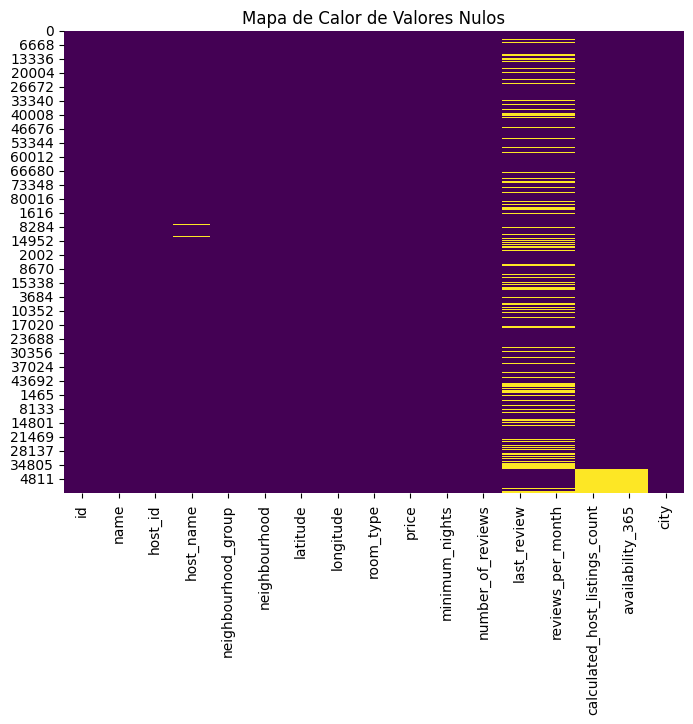

In [133]:
# Visualizar los nulos con un heatmap
# Visualizar nulos
plt.figure(figsize=(8, 6))
sns.heatmap(df_all.isnull(), cbar=False, cmap='viridis')
plt.title("Mapa de Calor de Valores Nulos")
plt.show()

#### Decidir que columnas eliminar

# Sección 4

<Axes: xlabel='price', ylabel='Count'>

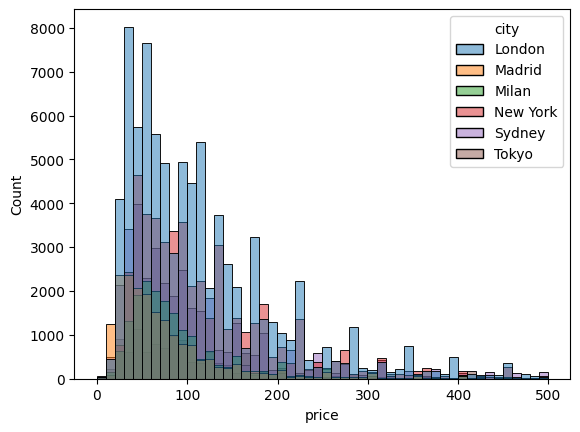

In [134]:
# Distribución de precios por ciudad
sns.histplot(data=df_all[df_all['price'] < 500], x="price", hue="city", bins=50)

<Axes: xlabel='room_type', ylabel='price'>

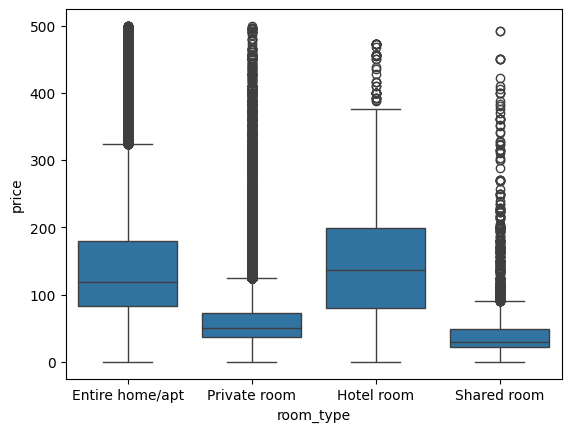

In [135]:
# Boxplot de precio por tipo de alojamiento
sns.boxplot(data=df_all[df_all['price'] < 500], x="room_type", y="price")

<Axes: xlabel='room_type', ylabel='count'>

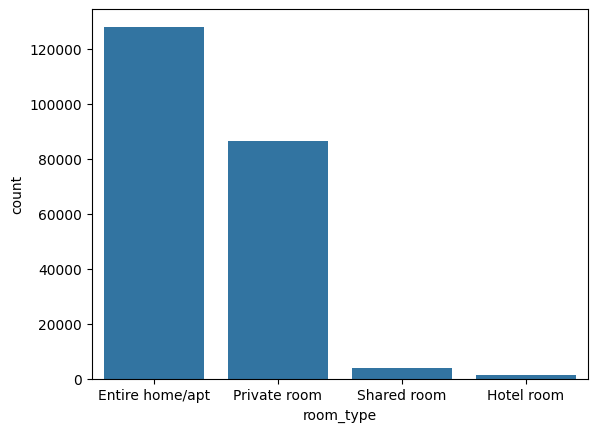

In [136]:
# Barras de tipo de alojamiento
sns.countplot(data=df_all, x="room_type", order=df_all['room_type'].value_counts().index)

### Análisis de variables numéricas

### Análisis de variables categóricas

### Guardar el fichero fusionado en raw/fusion_airbnb.csv

In [137]:
# Guardar DataFrame a CSV
df_all.to_csv('../data/raw/fusion_airbnb.csv', index=False, encoding='utf-8')